# Public Lecture 12 · Build a fixed-context character language model

**Repository file family:** L11 · **Topic:** Next-Token Prediction  
[Open this exact notebook in Colab](https://colab.research.google.com/github/nipunbatra/dl-teaching/blob/master/notebooks/L11/01_char_mlp_language_model.ipynb)

We use the same six-token vocabulary, tiny names corpus, and notation as the slides. You will make predictions before execution, verify the complete `.n → a` forward/backward pass, carry one sequence ledger through probability/NLL/perplexity, train a wider MLP, generate names, and expose the fixed-window limitation.

The numeric run is deterministic for the declared seed and environment, uses only NumPy and Matplotlib, and downloads nothing.

## 0 · Before running anything

Write down your predictions:

1. With context length $k=2$, how many training pairs does `naveen` create when `.` is also the end target?
2. For context `.n`, what are $c$, the ReLU mask, and the sign of the target-logit gradient?
3. Which embedding rows receive lookup gradients on `.n → a`? Does target row `a` receive one?
4. Why is sequence probability a product while NLL is a sum?
5. If two prefixes end in the same two characters, can this architecture distinguish them?

In [1]:
import logging
import math
import os
import tempfile
from pathlib import Path

# Configure a writable cache before importing Matplotlib. This keeps local and
# hosted runs quiet without writing machine-specific paths into saved output.
MPL_CACHE = Path(tempfile.gettempdir()) / 'dl-teaching-matplotlib'
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPL_CACHE)
logging.getLogger('matplotlib').setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=False)
SEED = 11
rng = np.random.default_rng(SEED)
print('NumPy', np.__version__, '| seed', SEED)

NumPy 2.5.2 | seed 11


## 1 · One tiny corpus, one vocabulary

The hand-worked slides use `[., a, e, i, n, v]`. Every name below uses only those characters. We split **whole names before windows** so no name contributes to both splits. Because a $k=2$ model can still encounter the same local contexts and transitions in different names, this tiny validation set measures held-out-name token NLL under the declared protocol; it does **not** establish broad name quality.

In [2]:
train_names = ['naveen', 'navin', 'neev', 'neena', 'vani', 'naina', 'avni', 'anvi', 'veena', 'navi']
valid_names = ['navina', 'naveena', 'veenavi', 'anvina']
chars = ['.', 'a', 'e', 'i', 'n', 'v']
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
V = len(chars)
print('vocabulary:', stoi)
print('train names:', train_names)
print('validation names:', valid_names)

vocabulary: {'.': 0, 'a': 1, 'e': 2, 'i': 3, 'n': 4, 'v': 5}
train names: ['naveen', 'navin', 'neev', 'neena', 'vani', 'naina', 'avni', 'anvi', 'veena', 'navi']
validation names: ['navina', 'naveena', 'veenavi', 'anvina']


## 2 · Slide a two-character window

Before running the next cell, manually list the seven context → target pairs for `naveen`. Check whether your first and final pairs include the boundary token `.`.

In [3]:
k = 2

def make_dataset(names):
    X, Y, rows = [], [], []
    for name in names:
        context = [stoi['.']] * k
        for target_char in name + '.':
            target = stoi[target_char]
            X.append(context.copy())
            Y.append(target)
            rows.append((name, ''.join(itos[i] for i in context), target_char))
            context = context[1:] + [target]
    return np.array(X, dtype=int), np.array(Y, dtype=int), rows

X_train, Y_train, train_rows = make_dataset(train_names)
X_valid, Y_valid, valid_rows = make_dataset(valid_names)

naveen_rows = [(context, target) for name, context, target in train_rows if name == 'naveen']
expected_rows = [('..', 'n'), ('.n', 'a'), ('na', 'v'), ('av', 'e'),
                 ('ve', 'e'), ('ee', 'n'), ('en', '.')]

print('naveen windows:')
for context, target in naveen_rows:
    print(f'  {context} -> {target}')
print('shapes:', X_train.shape, Y_train.shape, '| validation:', X_valid.shape, Y_valid.shape)
assert naveen_rows == expected_rows
assert X_train.shape == (56, 2) and X_valid.shape == (30, 2)

naveen windows:
  .. -> n
  .n -> a
  na -> v
  av -> e
  ve -> e
  ee -> n
  en -> .
shapes: (56, 2) (56,) | validation: (30, 2) (30,)


## 3 · Reproduce the exact `.n → a` forward pass

Predict first: the slides define $e_.=(1,0)$ and $e_n=(0,2)$. What is the concatenated context $c$? Which hidden ReLU should be active? Then estimate whether the target probability is above or below $0.5$.

In [4]:
E = np.array([[1., 0.], [0., 1.], [1., 1.], [-1., 1.], [0., 2.], [2., 0.]])
W_h = np.array([[0.5, 0., 0., 0.25], [0., 1., 1., 0.]])
b_h = np.array([0., -1.])
W_o = np.array([[-1., 0.], [2., 1.], [0., -1.], [-1., 1.], [0., 0.], [1., -1.]])
b_o = np.zeros(V)

x = np.array([stoi['.'], stoi['n']])
target = stoi['a']
embedded = E[x]
c = embedded.reshape(-1)
u = W_h @ c + b_h
h = np.maximum(0., u)
z = W_o @ h + b_o
exp_z = np.exp(z - z.max())
p = exp_z / exp_z.sum()
loss = -np.log(p[target])

print('looked-up rows =\n', embedded)
print('c =', c)
print('u =', u, ' h =', h)
print('z =', z)
print('p =', p, ' sum =', p.sum())
print(f'p(a | .n) = {p[target]:.6f} | token NLL = {loss:.6f} nats')
assert np.allclose(c, [1., 0., 0., 2.])
assert np.allclose(u, [1., -1.]) and np.allclose(h, [1., 0.])
assert np.allclose(z, [-1., 2., 0., -1., 0., 1.])
assert np.allclose(p, [0.0286441383, 0.5753328974, 0.0778628406,
                       0.0286441383, 0.0778628406, 0.2116531448])
assert np.isclose(loss, 0.5528064537)

looked-up rows =
 [[1. 0.]
 [0. 2.]]
c = [1. 0. 0. 2.]
u = [ 1. -1.]  h = [1. 0.]
z = [-1.  2.  0. -1.  0.  1.]
p = [0.028644 0.575333 0.077863 0.028644 0.077863 0.211653]  sum = 1.0
p(a | .n) = 0.575333 | token NLL = 0.552806 nats


### Read the probability vector

Match each coordinate of `p` to `[., a, e, i, n, v]`. The scalar loss reads $p_a$, but softmax couples that probability to all six logits; therefore all six logits receive a gradient.

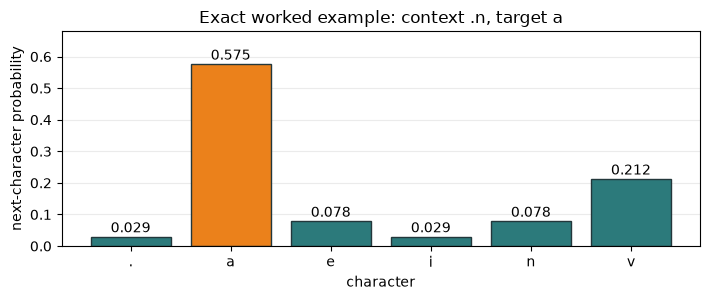

In [5]:
plt.figure(figsize=(7.2, 3.1))
colors = ['#EB811B' if ch == 'a' else '#2C7A7B' for ch in chars]
bars = plt.bar(chars, p, color=colors, edgecolor='#23373B')
plt.ylim(0, 0.68); plt.ylabel('next-character probability'); plt.xlabel('character')
plt.grid(axis='y', alpha=.25); plt.gca().set_axisbelow(True)
for bar, value in zip(bars, p):
    plt.text(bar.get_x() + bar.get_width()/2, value + .015, f'{value:.3f}', ha='center')
plt.title('Exact worked example: context .n, target a')
plt.tight_layout(); plt.show()

## 4 · Backpropagate every number by hand-coded NumPy

The key identity is $\nabla_z\mathcal{L}=p-y$. Predict the sign of the target coordinate before running the cell.

In [6]:
y = np.zeros(V); y[target] = 1.
dz = p - y
dW_o = np.outer(dz, h)
db_o = dz.copy()
dh = W_o.T @ dz
du = dh * (u > 0)
dW_h = np.outer(du, c)
db_h = du.copy()
dc = W_h.T @ du
d_embedded = dc.reshape(k, -1)
dE = np.zeros_like(E)
np.add.at(dE, x, d_embedded)

print('dz = p-y =', dz)
print('dW_o =\n', dW_o)
print('db_o =', db_o)
print('dh =', dh, '| ReLU mask =', (u > 0).astype(int), '| du =', du)
print('dW_h =\n', dW_h)
print('db_h =', db_h)
print('dc =', dc)
print('dE row . =', dE[stoi['.']], '| dE row n =', dE[stoi['n']])
print('nonzero embedding rows:', [chars[i] for i in np.where(np.abs(dE).sum(axis=1) > 0)[0]])

expected_dz = np.array([0.0286441383, -0.4246671026, 0.0778628406,
                        0.0286441383, 0.0778628406, 0.2116531448])
expected_dh = np.array([-0.6949693370, -0.6855389497])
expected_dc = np.array([-0.3474846685, 0., 0., -0.1737423343])
assert np.allclose(dz, expected_dz)
assert np.allclose(dW_o, np.outer(expected_dz, [1., 0.]))
assert np.allclose(db_o, expected_dz)
assert np.allclose(dh, expected_dh) and np.allclose(du, [expected_dh[0], 0.])
assert np.allclose(dW_h, np.outer([expected_dh[0], 0.], c))
assert np.allclose(db_h, [expected_dh[0], 0.])
assert np.allclose(dc, expected_dc)
assert np.allclose(dE[stoi['.']], [-0.3474846685, 0.])
assert np.allclose(dE[stoi['n']], [0., -0.1737423343])
assert np.count_nonzero(np.abs(dE).sum(axis=1)) == 2

dz = p-y = [ 0.028644 -0.424667  0.077863  0.028644  0.077863  0.211653]
dW_o =
 [[ 0.028644  0.      ]
 [-0.424667 -0.      ]
 [ 0.077863  0.      ]
 [ 0.028644  0.      ]
 [ 0.077863  0.      ]
 [ 0.211653  0.      ]]
db_o = [ 0.028644 -0.424667  0.077863  0.028644  0.077863  0.211653]
dh = [-0.694969 -0.685539] | ReLU mask = [1 0] | du = [-0.694969 -0.      ]
dW_h =
 [[-0.694969 -0.       -0.       -1.389939]
 [-0.       -0.       -0.       -0.      ]]
db_h = [-0.694969 -0.      ]
dc = [-0.347485  0.        0.       -0.173742]
dE row . = [-0.347485  0.      ] | dE row n = [ 0.       -0.173742]
nonzero embedding rows: ['.', 'n']


### Explain, do not merely inspect

1. Why is the second column of `dW_o` zero?
2. Why is `dz[a]` nonzero while embedding row `dE[a]` is zero?
3. Which forward-pass value must be stored to decide the ReLU mask?

## 5 · Carry one sequence ledger through probability, NLL, and perplexity

Only the orange `.n → a` probability comes from the exact weights above. The other six correct-target probabilities are the slides' declared **illustrative** values. Predict first: should multiplying seven probabilities produce a number larger or smaller than each factor?

In [7]:
ledger_contexts = ['..', '.n', 'na', 'av', 've', 'ee', 'en']
ledger_targets = list('naveen.')
ledger_target_prob = np.array([.30, p[target], .70, .60, .50, .40, .80])
token_nll = -np.log(ledger_target_prob)
sequence_probability = float(ledger_target_prob.prod())
total_nll = float(token_nll.sum())
mean_nll = float(token_nll.mean())
perplexity = math.exp(mean_nll)

print('context  target  p(target)  token NLL')
for context, target_char, prob_i, nll_i in zip(
        ledger_contexts, ledger_targets, ledger_target_prob, token_nll):
    marker = '  <- exact weights' if context == '.n' else '  <- illustrative'
    print(f'{context:>7}  {target_char:^6}  {prob_i:>9.6f}  {nll_i:>9.6f}{marker}')
print(f'\nsequence probability = {sequence_probability:.7f}')
print(f'total NLL            = {total_nll:.5f} nats')
print(f'mean NLL             = {mean_nll:.6f} nats/token')
print(f'perplexity           = {perplexity:.5f}')

assert np.isclose(sequence_probability, 0.0115987112)
assert np.isclose(total_nll, 4.4568612895)
assert np.isclose(mean_nll, 0.6366944699)
assert np.isclose(perplexity, 1.8902223543)
assert np.isclose(-math.log(sequence_probability), total_nll)
assert np.isclose(math.exp(total_nll / len(ledger_targets)), perplexity)

context  target  p(target)  token NLL
     ..    n      0.300000   1.203973  <- illustrative
     .n    a      0.575333   0.552806  <- exact weights
     na    v      0.700000   0.356675  <- illustrative
     av    e      0.600000   0.510826  <- illustrative
     ve    e      0.500000   0.693147  <- illustrative
     ee    n      0.400000   0.916291  <- illustrative
     en    .      0.800000   0.223144  <- illustrative

sequence probability = 0.0115987
total NLL            = 4.45686 nats
mean NLL             = 0.636694 nats/token
perplexity           = 1.89022


The product and sum are the same likelihood in different coordinates: $-\log\prod_t p_t=\sum_t-\log p_t$. Perplexity here is $\exp($token-weighted mean NLL$)$. This one-name illustrative ledger is **not** the trained model's validation score.

## 6 · Train a wider version on the tiny corpus

We now keep the architecture class but widen it to $d=4,H=24$. This executable uses **300 full-batch Adam steps**: all 56 training pairs form $B$ on every step. That is not a minibatch claim, not the generic optimizer-agnostic batch/update diagram in the lecture, and not the lecture's one-example $\eta=.1$ plain-gradient-descent illustration. Full-batch Adam is used here only to keep the run short and reproducible.

In [8]:
d, H = 4, 24
rng = np.random.default_rng(SEED)
params = {
    'E': rng.normal(0, .15, (V, d)),
    'Wh': rng.normal(0, .18, (H, k*d)),
    'bh': np.full(H, .05),
    'Wo': rng.normal(0, .18, (V, H)),
    'bo': np.zeros(V),
}

def forward(X, P):
    emb = P['E'][X]
    c = emb.reshape(len(X), k*d)
    u = c @ P['Wh'].T + P['bh']
    h = np.maximum(0., u)
    z = h @ P['Wo'].T + P['bo']
    shifted = z - z.max(axis=1, keepdims=True)
    prob = np.exp(shifted); prob /= prob.sum(axis=1, keepdims=True)
    return prob, (X, emb, c, u, h, prob)

def loss_and_grads(X, Y, P):
    prob, cache = forward(X, P)
    X, emb, c, u, h, prob = cache
    N = len(X)
    loss = -np.log(prob[np.arange(N), Y] + 1e-12).mean()
    dz = prob.copy(); dz[np.arange(N), Y] -= 1.; dz /= N
    grads = {}
    grads['Wo'] = dz.T @ h; grads['bo'] = dz.sum(axis=0)
    dh = dz @ P['Wo']; du = dh * (u > 0)
    grads['Wh'] = du.T @ c; grads['bh'] = du.sum(axis=0)
    dc = du @ P['Wh']; demb = dc.reshape(N, k, d)
    grads['E'] = np.zeros_like(P['E'])
    np.add.at(grads['E'], X.reshape(-1), demb.reshape(-1, d))
    return loss, grads

def mean_nll(X, Y, P):
    prob, _ = forward(X, P)
    return float(-np.log(prob[np.arange(len(Y)), Y] + 1e-12).mean())

m = {name: np.zeros_like(value) for name, value in params.items()}
v = {name: np.zeros_like(value) for name, value in params.items()}
train_history, valid_history = [], []
lr, beta1, beta2 = .02, .9, .999
for step in range(1, 301):
    batch_loss, grads = loss_and_grads(X_train, Y_train, params)
    if step == 300:
        # This is the train objective displayed in the frozen lecture deck.
        lecture_train_nll = float(batch_loss)
    for name in params:
        m[name] = beta1*m[name] + (1-beta1)*grads[name]
        v[name] = beta2*v[name] + (1-beta2)*(grads[name]**2)
        mhat = m[name] / (1-beta1**step)
        vhat = v[name] / (1-beta2**step)
        params[name] -= lr * mhat / (np.sqrt(vhat) + 1e-8)
    # Both curves now evaluate the same post-update parameter snapshot.
    train_history.append(mean_nll(X_train, Y_train, params))
    valid_history.append(mean_nll(X_valid, Y_valid, params))

final_train_nll = train_history[-1]
final_valid_nll = valid_history[-1]
print('optimizer: full-batch Adam | batch size 56 | steps 300')
print('lecture checkpoint (train objective used to compute update 300):')
print(f'  train NLL {lecture_train_nll:.6f} | PPL {math.exp(lecture_train_nll):.5f}')
print('same final parameter snapshot (after update 300):')
print(f'  train NLL {final_train_nll:.6f} | PPL {math.exp(final_train_nll):.5f}')
print(f'  valid NLL {final_valid_nll:.6f} | PPL {math.exp(final_valid_nll):.5f}')
print('caveat: four held-out names; this is not evidence of broad name quality')
assert np.isclose(lecture_train_nll, 0.6452794221)
assert np.isclose(math.exp(lecture_train_nll), 1.9065196785)
assert np.isclose(final_train_nll, 0.6453079240)
assert np.isclose(final_valid_nll, 0.6779647178)
assert np.isclose(math.exp(final_train_nll), 1.9065740189)
assert np.isclose(math.exp(final_valid_nll), 1.9698644194)

optimizer: full-batch Adam | batch size 56 | steps 300
lecture checkpoint (train objective used to compute update 300):
  train NLL 0.645279 | PPL 1.90652
same final parameter snapshot (after update 300):
  train NLL 0.645308 | PPL 1.90657
  valid NLL 0.677965 | PPL 1.96986
caveat: four held-out names; this is not evidence of broad name quality


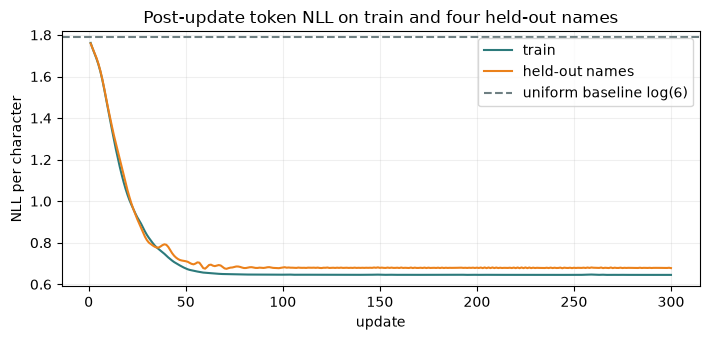

In [9]:
plt.figure(figsize=(7.2, 3.5))
updates = np.arange(1, len(train_history) + 1)
plt.plot(updates, train_history, label='train', color='#2C7A7B')
plt.plot(updates, valid_history, label='held-out names', color='#EB811B')
plt.axhline(math.log(V), color='#6E7F82', ls='--', label=f'uniform baseline log({V})')
plt.xlabel('update'); plt.ylabel('NLL per character'); plt.legend(); plt.grid(alpha=.2)
plt.title('Post-update token NLL on train and four held-out names')
plt.tight_layout(); plt.show()

### Inspect the learned representation

The four embedding coordinates are not directly drawable, so the plot shows coordinates 1 and 2 exactly—not a distance-preserving projection. Apparent proximity may differ in the full 4-D space, and any learned geometry reflects this tiny corpus rather than universal linguistic structure.

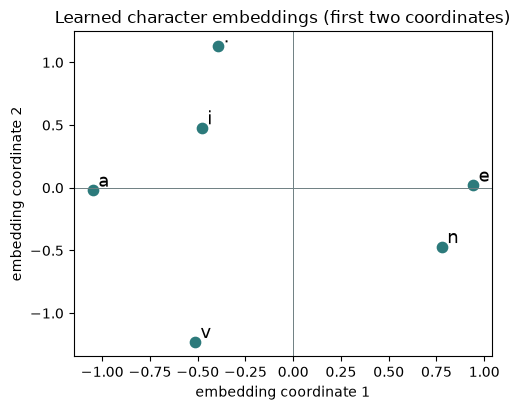

In [10]:
plt.figure(figsize=(5.2, 4.2))
for i, ch in enumerate(chars):
    plt.scatter(params['E'][i,0], params['E'][i,1], s=55, color='#2C7A7B')
    plt.text(params['E'][i,0]+.03, params['E'][i,1]+.03, ch, fontsize=13)
plt.axhline(0, color='#6E7F82', lw=.7); plt.axvline(0, color='#6E7F82', lw=.7)
plt.xlabel('embedding coordinate 1'); plt.ylabel('embedding coordinate 2')
plt.title('Learned character embeddings (first two coordinates)')
plt.tight_layout(); plt.show()

## 7 · Generate autoregressively

From this point onward, `next_distribution` uses the **trained widened MLP**, not the two-unit hand-worked model. At each step: run the current two-character context, divide logits by positive temperature, choose one character, append it, and repeat. Before running, predict the greedy first token from `..` and which temperature should produce the higher-entropy distribution for a fixed context. Temperature changes concentration—not weights or token ranking—and lower temperature is not automatically safer or more correct.

In [11]:
def next_distribution(context, temperature=1.0):
    if temperature <= 0:
        raise ValueError('temperature must be positive')
    X = np.array([[stoi[ch] for ch in context]], dtype=int)
    emb = params['E'][X].reshape(1, k*d)
    h = np.maximum(0., emb @ params['Wh'].T + params['bh'])
    z = (h @ params['Wo'].T + params['bo'])[0] / temperature
    q = np.exp(z-z.max()); return q/q.sum()

def generate(temperature, generator, max_length=12):
    context = ['.'] * k
    output = []
    for _ in range(max_length):
        prob = next_distribution(context, temperature)
        idx = generator.choice(V, p=prob)
        ch = itos[idx]
        if ch == '.': break
        output.append(ch); context = context[1:] + [ch]
    return ''.join(output)

def entropy(prob):
    return float(-(prob * np.log(prob)).sum())

fixed_context = '.n'
for temperature in (0.5, 1.0, 2.0):
    prob_t = next_distribution(fixed_context, temperature)
    print(f'T={temperature:.1f}  entropy={entropy(prob_t):.6f}  '
          f'top={itos[int(prob_t.argmax())]}  p={prob_t}')

greedy_first = itos[int(next_distribution('..').argmax())]
print('\ngreedy first token from ..:', greedy_first)

# Deterministic sample rows are qualitative examples, not a controlled estimate
# of diversity. The fixed-context entropy table above is the controlled test.
for temperature in (0.5, 1.0, 2.0):
    generator = np.random.default_rng(110)
    samples = [generate(temperature, generator) for _ in range(8)]
    print(f'samples T={temperature:.1f}:', ', '.join(samples))

entropies = [entropy(next_distribution(fixed_context, t)) for t in (.5, 1., 2.)]
assert entropies[0] < entropies[1] < entropies[2]
assert all(next_distribution(fixed_context, t).argmax() == target for t in (.5, 1., 2.))

T=0.5  entropy=0.501848  top=a  p=[1.300031e-08 7.989552e-01 2.010448e-01 6.673566e-16 3.939092e-15
 8.658738e-09]
T=1.0  entropy=0.638532  top=a  p=[8.493468e-05 6.658394e-01 3.340063e-01 1.924364e-08 4.675266e-08
 6.931633e-05]
T=2.0  entropy=0.747856  top=a  p=[6.527749e-03 5.779705e-01 4.093533e-01 9.825723e-05 1.531525e-04
 5.897103e-03]

greedy first token from ..: n
samples T=0.5: veenaveenavi, avi, navinain, navin, navi, navi, veenaveev, neev
samples T=1.0: veen, vani, na, navina, veev, navin, navi, navinaveev
samples T=2.0: veen, vani, na, navinainain, navni, anvi, naveev, anvi


## 8 · Expose the fixed-window limitation

A $k=2$ model sees only the suffix. Predict first: the prefixes `na` and `veena` both end in `na`; can any optimizer or additional training make this architecture produce different distributions for them?

In [12]:
prefix_a, prefix_b = 'na', 'veena'
context_a, context_b = prefix_a[-k:], prefix_b[-k:]
pa = next_distribution(context_a)
pb = next_distribution(context_b)
print(prefix_a, '-> visible context', context_a, '->',
      np.array2string(pa, precision=9, suppress_small=False))
print(prefix_b, '-> visible context', context_b, '->',
      np.array2string(pb, precision=9, suppress_small=False))
print('maximum absolute difference:', np.max(np.abs(pa - pb)))
print('identical?', np.array_equal(pa, pb))
assert context_a == context_b == 'na'
assert np.array_equal(pa, pb)
assert np.allclose(pa, [0.418670976, 9.91178e-7, 3.773631e-6,
                        0.142727840, 3.1723076e-5, 0.438564696])

na -> visible context na -> [4.186709761e-01 9.911782138e-07 3.773631003e-06 1.427278403e-01
 3.172307561e-05 4.385646957e-01]
veena -> visible context na -> [4.186709761e-01 9.911782138e-07 3.773631003e-06 1.427278403e-01
 3.172307561e-05 4.385646957e-01]
maximum absolute difference: 0.0
identical? True


## 9 · Final explain-back and handoff

Answer these in your own words:

1. Why is language modeling repeated classification?
2. Why does concatenating embeddings preserve order while averaging does not?
3. Trace the `.n → a` loss backward to the two embedding rows.
4. Relate sequence probability, total NLL, mean NLL, and perplexity without changing the evaluation contract.
5. What changes when temperature changes? What does **not** change?
6. Give one dependency that a two-character context can never represent.

If you can explain all six without looking back, you are ready for public Lecture 13: RNNs, LSTMs, and GRUs, where a shared recurrent state replaces the fixed window.

Primary context: [Bengio et al. (2003), *A Neural Probabilistic Language Model*](https://www.jmlr.org/papers/v3/bengio03a.html).